# Bubble Detection — No SMOTE, Loose Labels (conf >= 0.05)

**Motivation**: previous SMOTE-based models detected bubbles from only one cluster.
Here we use much looser LPPLS labels (conf >= 0.05 for all metals), giving
3-7x more bubble days spread across many more clusters. With enough positives,
we train **without SMOTE** and check whether multiple bubble episodes are detected.

| Metal | Bubble days | Clusters | Prevalence |
|-------|------------|----------|------------|
| Cobalt | 64 | 8 | 3.0% |
| Copper | 143 | 31 | 6.6% |
| Lithium | 83 | 15 | 3.9% |
| Nickel | 129 | 27 | 6.0% |

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os, warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                              precision_recall_curve, roc_curve)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
os.makedirs('outputs', exist_ok=True)

LOOSE_CSV = '../R/df_master_lppls_loose.csv'
assert os.path.exists(LOOSE_CSV), (
    f'{LOOSE_CSV} not found -- run lppls_data_prep.ipynb Section 8 first')

# ── Helpers ─────────────────────────────────────────────────────────────────

def prepare_ml_data(target_col, df_master):
    """Lagged feature matrix (same as other notebooks, no look-ahead)."""
    target_dummy = target_col + '_BD'
    bubble_cols  = [c for c in df_master.columns if c.endswith('_BD')]
    num_cols     = [c for c in df_master.select_dtypes(include='number').columns
                    if c not in bubble_cols]
    peer_dummies = [c for c in bubble_cols if c != target_dummy]
    df = df_master[['Date'] + num_cols + bubble_cols].copy().sort_values('Date').reset_index(drop=True)
    for col in num_cols:
        safe = df[col].clip(lower=0.001)
        lr = np.log(safe).diff()
        df[col + '_Ret'] = lr
        df[col + '_Vol'] = lr.rolling(10).std()
    lagged = {}
    for c in [c for c in df.columns if c.endswith('_Ret')]:
        lagged[c + '_Lag1'] = df[c].shift(1)
    for c in [c for c in df.columns if c.endswith('_Vol')]:
        lagged[c + '_Lag1'] = df[c].shift(1)
    for c in num_cols:
        lagged[c + '_Level_Lag1'] = df[c].shift(1)
    for c in peer_dummies:
        lagged[c + '_Lag1'] = df[c].shift(1).fillna(0)
    df_out = pd.DataFrame(lagged, index=df.index)
    df_out['Date']   = df['Date']
    df_out['Target'] = df[target_dummy].astype(int)
    return df_out.dropna().reset_index(drop=True)

def find_f1_threshold(y_true, y_prob):
    pre, rec, thr = precision_recall_curve(y_true, y_prob)
    with np.errstate(invalid='ignore'):
        f1s = np.where((pre[:-1]+rec[:-1])>0,
                       2*pre[:-1]*rec[:-1]/(pre[:-1]+rec[:-1]), 0.0)
    i = int(np.argmax(f1s))
    return float(thr[i]), float(f1s[i])

def label_clusters(y):
    """Return array same length as y with cluster id (1-based) for positives, 0 for negatives."""
    clusters = np.zeros(len(y), dtype=int)
    cid = 0
    in_b = False
    for i in range(len(y)):
        if y[i] == 1 and not in_b:
            cid += 1; in_b = True
        elif y[i] == 0:
            in_b = False
        if y[i] == 1:
            clusters[i] = cid
    return clusters

print('Setup complete.')


Setup complete.


## 1. Load Data & Bubble Overview

Period: 2017-05-10 to 2025-10-31 (2152 days)

Metal        Days   Prev%  Clusters
--------------------------------------
Cobalt         64    3.0%         8
Copper        143    6.6%        31
Lithium        83    3.9%        15
Nickel        129    6.0%        27


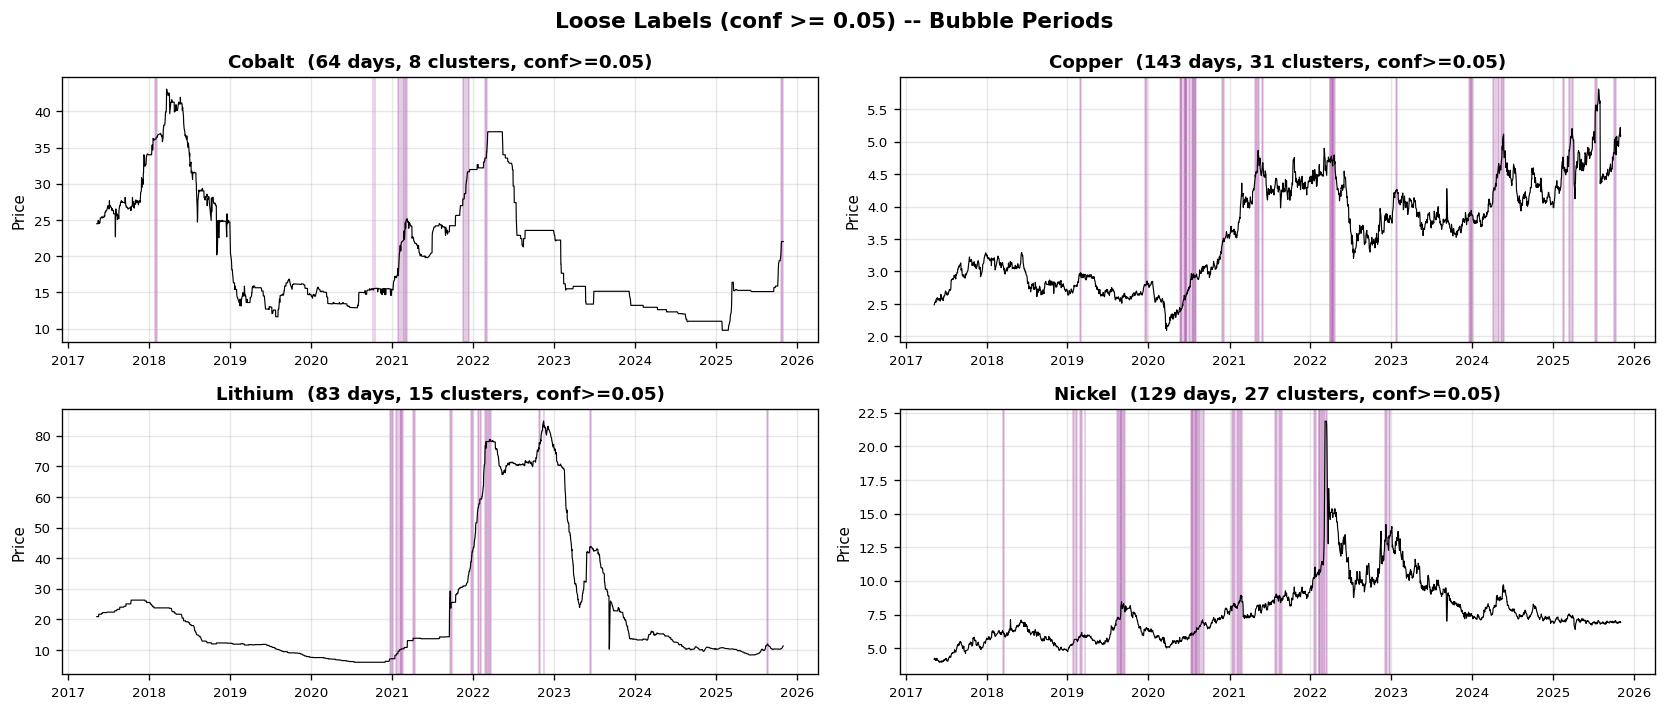

In [2]:
df = pd.read_csv(LOOSE_CSV, sep=';', decimal=',', index_col=0)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

metal_map = {
    'Cobalt':  ('CODALY', 'CODALY_BD'),
    'Copper':  ('CUDALY', 'CUDALY_BD'),
    'Lithium': ('LIDALY', 'LIDALY_BD'),
    'Nickel':  ('NIDALY', 'NIDALY_BD'),
}

print(f'Period: {df["Date"].min().date()} to {df["Date"].max().date()} ({len(df)} days)\n')
print(f'{"Metal":10s}  {"Days":>5s}  {"Prev%":>6s}  {"Clusters":>8s}')
print('-' * 38)
for metal, (pcol, dcol) in metal_map.items():
    bub = df[dcol].values
    n = int(bub.sum())
    cl = label_clusters(bub)
    nc = cl.max()
    print(f'{metal:10s}  {n:5d}  {100*n/len(df):5.1f}%  {nc:8d}')

# ── Timeline with bubble clusters numbered ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for idx, (metal, (pcol, dcol)) in enumerate(metal_map.items()):
    ax = axes.flat[idx]
    dates = df['Date']
    ax.plot(dates, df[pcol], color='black', lw=0.7)
    bub = df[dcol].values
    cl = label_clusters(bub)
    nc = cl.max()
    in_b = False
    for i in range(len(bub)):
        if bub[i] == 1 and not in_b:
            s = dates.iloc[i]; in_b = True
        elif (bub[i] == 0 or i == len(bub) - 1) and in_b:
            ax.axvspan(s, dates.iloc[i], color='purple', alpha=0.2)
            in_b = False
    ax.set_title(f'{metal}  ({int(bub.sum())} days, {nc} clusters, conf>=0.05)',
                 fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.set_ylabel('Price', fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle('Loose Labels (conf >= 0.05) -- Bubble Periods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/nosmote_bubble_timelines.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


## 2. Train Models (No SMOTE) — All Metals

3 models x 4 metals, 5-fold expanding-window TimeSeriesSplit.
No SMOTE, no class weighting — just the raw (imbalanced) data with more positives.

In [3]:
models_def = {
    'LASSO': lambda: LogisticRegression(
        penalty='l1', solver='saga', C=0.1, max_iter=10000, random_state=42),
    'RandomForest': lambda: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=3,
        max_features='sqrt', random_state=42),
    'XGBoost': lambda: xgb.XGBClassifier(
        max_depth=3, learning_rate=0.05, n_estimators=300,
        min_child_weight=2, reg_alpha=0.5, reg_lambda=2.0,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='auc',
        verbosity=0, random_state=42),
}

N_SPLITS = 5
results = []        # rows for results table
cv_preds = {}       # (metal, model) -> DataFrame with Date, y_true, y_prob

for metal, (pcol, dcol) in metal_map.items():
    df_ml = prepare_ml_data(pcol, df)
    feats = [c for c in df_ml.columns if c not in ['Date', 'Target']]
    X = df_ml[feats].values
    y = df_ml['Target'].values
    dates_arr = df_ml['Date']

    n_pos = int(y.sum())
    print(f'\n{metal}  --  {n_pos} bubble days / {len(y)} total ({100*y.mean():.1f}%)')

    for mname, model_fn in models_def.items():
        scale = (mname == 'LASSO')
        tscv = TimeSeriesSplit(n_splits=N_SPLITS)
        all_p, all_t, all_d = [], [], []

        for train_idx, test_idx in tscv.split(X):
            Xtr, Xte = X[train_idx], X[test_idx]
            ytr, yte = y[train_idx], y[test_idx]
            d_te = dates_arr.iloc[test_idx].values

            if ytr.sum() < 5 or yte.sum() == 0:
                continue

            if scale:
                sc = StandardScaler()
                Xtr = sc.fit_transform(Xtr)
                Xte = sc.transform(Xte)

            m = model_fn()
            m.fit(Xtr, ytr)
            p = m.predict_proba(Xte)[:, 1]
            all_p.append(p); all_t.append(yte); all_d.append(d_te)

        if not all_p:
            print(f'  {mname:15s}: no valid fold')
            continue

        pred_df = pd.DataFrame({
            'Date': pd.to_datetime(np.concatenate(all_d)),
            'y_true': np.concatenate(all_t),
            'y_prob': np.concatenate(all_p),
        }).sort_values('Date').reset_index(drop=True)
        cv_preds[(metal, mname)] = pred_df

        yt = pred_df['y_true'].values
        yp = pred_df['y_prob'].values
        auc = roc_auc_score(yt, yp)
        opt_t, opt_f1 = find_f1_threshold(yt, yp)
        ypred = (yp >= opt_t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, ypred, labels=[0,1]).ravel()
        sens = tp/(tp+fn) if (tp+fn) > 0 else 0
        spec = tn/(tn+fp) if (tn+fp) > 0 else 0
        prec = tp/(tp+fp) if (tp+fp) > 0 else 0

        # Per-cluster detection
        cl = label_clusters(pred_df['y_true'].values)
        clusters_total = set(cl[cl > 0])
        cl_pred = label_clusters(pred_df['y_true'].values)  # cluster ids for true
        detected_clusters = set()
        for c_id in clusters_total:
            mask = cl == c_id
            if ypred[mask].sum() > 0:
                detected_clusters.add(c_id)
        n_cl_det = len(detected_clusters)
        n_cl_tot = len(clusters_total)

        results.append(dict(
            Metal=metal, Model=mname, BubDays=n_pos,
            AUC=round(auc, 3), F1_opt=round(opt_f1, 3), T_opt=round(opt_t, 4),
            Sens=round(sens, 3), Spec=round(spec, 3), Prec=round(prec, 3),
            Detected=f'{tp}/{tp+fn}',
            ClustersDet=f'{n_cl_det}/{n_cl_tot}',
        ))
        print(f'  {mname:15s}:  AUC={auc:.3f}  F1={opt_f1:.3f}  '
              f'Sens={sens:.3f}  Det={tp}/{tp+fn}  '
              f'Clusters={n_cl_det}/{n_cl_tot}')

df_res = pd.DataFrame(results)
df_res.to_csv('outputs/nosmote_loose_results.csv', index=False)
print(f'\nSaved -> outputs/nosmote_loose_results.csv')



Cobalt  --  64 bubble days / 2141 total (3.0%)
  LASSO          :  AUC=0.909  F1=0.515  Sens=0.593  Det=35/59  Clusters=5/7
  RandomForest   :  AUC=0.744  F1=0.236  Sens=0.864  Det=51/59  Clusters=5/7
  XGBoost        :  AUC=0.683  F1=0.181  Sens=0.559  Det=33/59  Clusters=4/7

Copper  --  143 bubble days / 2141 total (6.7%)
  LASSO          :  AUC=0.535  F1=0.242  Sens=0.383  Det=51/133  Clusters=7/28
  RandomForest   :  AUC=0.543  F1=0.311  Sens=0.316  Det=42/133  Clusters=6/28
  XGBoost        :  AUC=0.565  F1=0.234  Sens=0.256  Det=34/133  Clusters=7/28

Lithium  --  83 bubble days / 2141 total (3.9%)
  LASSO          :  AUC=0.724  F1=0.208  Sens=0.333  Det=15/45  Clusters=4/10
  RandomForest   :  AUC=0.639  F1=0.162  Sens=0.311  Det=14/45  Clusters=6/10
  XGBoost        :  AUC=0.744  F1=0.224  Sens=0.267  Det=12/45  Clusters=5/10

Nickel  --  129 bubble days / 2141 total (6.0%)
  LASSO          :  AUC=0.549  F1=0.264  Sens=0.694  Det=68/98  Clusters=17/19
  RandomForest   :  AUC=

## 3. Results Table & Cluster Detection

No-SMOTE, Loose Labels (conf >= 0.05) — Results
   Metal            Model  BubDays    AUC  F1@opt   Sens   Prec  Detected   Clusters
------------------------------------------------------------------------------------------
  Cobalt            LASSO       64  0.909   0.515  0.593  0.455     35/59        5/7
  Cobalt     RandomForest       64  0.744   0.236  0.864  0.136     51/59        5/7
  Cobalt          XGBoost       64  0.683   0.181  0.559  0.108     33/59        4/7

  Copper     RandomForest      143  0.543   0.311  0.316  0.307    42/133       6/28
  Copper            LASSO      143  0.535   0.242  0.383  0.177    51/133       7/28
  Copper          XGBoost      143  0.565   0.234  0.256  0.217    34/133       7/28

 Lithium          XGBoost       83  0.744   0.224  0.267  0.194     12/45       5/10
 Lithium            LASSO       83  0.724   0.208  0.333  0.152     15/45       4/10
 Lithium     RandomForest       83  0.639   0.162  0.311  0.109     14/45       6/10

  Nickel

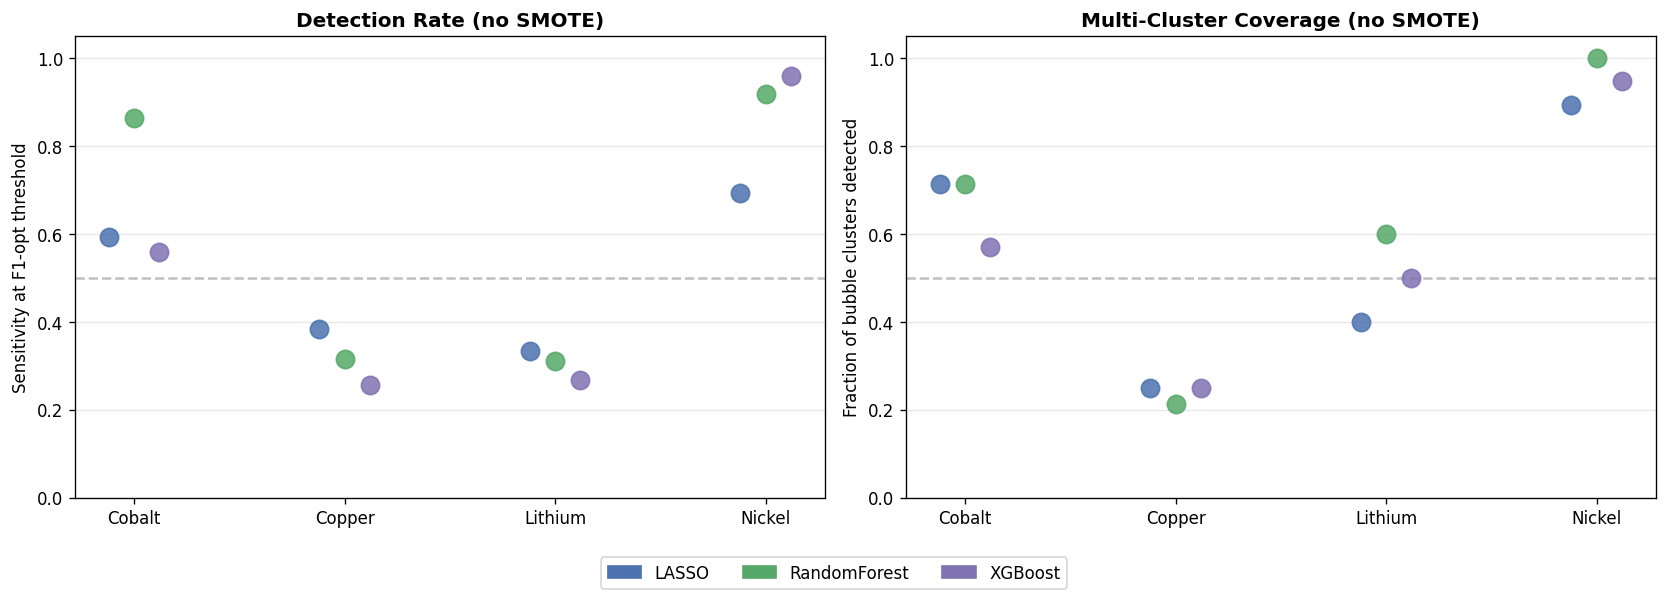

In [4]:
# ── Full results table ────────────────────────────────────────────────────────
print('No-SMOTE, Loose Labels (conf >= 0.05) — Results')
print('=' * 90)
print(f'{"Metal":>8s}  {"Model":>15s}  {"BubDays":>7s}  {"AUC":>5s}  '
      f'{"F1@opt":>6s}  {"Sens":>5s}  {"Prec":>5s}  {"Detected":>8s}  {"Clusters":>9s}')
print('-' * 90)
for metal in ['Cobalt', 'Copper', 'Lithium', 'Nickel']:
    sub = df_res[df_res.Metal == metal].sort_values('F1_opt', ascending=False)
    for _, r in sub.iterrows():
        print(f'{r.Metal:>8s}  {r.Model:>15s}  {int(r.BubDays):>7d}  {r.AUC:>5.3f}  '
              f'{r.F1_opt:>6.3f}  {r.Sens:>5.3f}  {r.Prec:>5.3f}  {r.Detected:>8s}  '
              f'{r.ClustersDet:>9s}')
    print()

# ── Chart: clusters detected per metal ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pal = {'LASSO': '#4C72B0', 'RandomForest': '#55A868', 'XGBoost': '#8172B2'}

# Left: Sensitivity
ax = axes[0]
for metal in ['Cobalt', 'Copper', 'Lithium', 'Nickel']:
    sub = df_res[df_res.Metal == metal]
    x_pos = {'Cobalt': 0, 'Copper': 1, 'Lithium': 2, 'Nickel': 3}[metal]
    for j, (_, r) in enumerate(sub.iterrows()):
        ax.scatter(x_pos + (j-1)*0.12, r.Sens,
                   c=pal.get(r.Model, '#888'), s=120, alpha=0.85, zorder=4)
ax.set_xticks(range(4))
ax.set_xticklabels(['Cobalt', 'Copper', 'Lithium', 'Nickel'])
ax.axhline(0.5, color='grey', ls='--', alpha=0.5)
ax.set_ylabel('Sensitivity at F1-opt threshold')
ax.set_title('Detection Rate (no SMOTE)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05); ax.grid(axis='y', alpha=0.3)

# Right: Cluster detection fraction
ax = axes[1]
for metal in ['Cobalt', 'Copper', 'Lithium', 'Nickel']:
    sub = df_res[df_res.Metal == metal]
    x_pos = {'Cobalt': 0, 'Copper': 1, 'Lithium': 2, 'Nickel': 3}[metal]
    for j, (_, r) in enumerate(sub.iterrows()):
        a, b = r.ClustersDet.split('/')
        frac = int(a) / int(b) if int(b) > 0 else 0
        ax.scatter(x_pos + (j-1)*0.12, frac,
                   c=pal.get(r.Model, '#888'), s=120, alpha=0.85, zorder=4)
ax.set_xticks(range(4))
ax.set_xticklabels(['Cobalt', 'Copper', 'Lithium', 'Nickel'])
ax.axhline(0.5, color='grey', ls='--', alpha=0.5)
ax.set_ylabel('Fraction of bubble clusters detected')
ax.set_title('Multi-Cluster Coverage (no SMOTE)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.05); ax.grid(axis='y', alpha=0.3)

# Legend
import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=m) for m, c in pal.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10)
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('outputs/nosmote_results_overview.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


## 4. Timeline Plots — Per-Metal Detection

For each metal, show the price series with bubble periods shaded and the
predicted probability coloured by outcome (TP/FP/FN/TN).
Focus: are bubbles from **multiple clusters** detected (green), or just one?

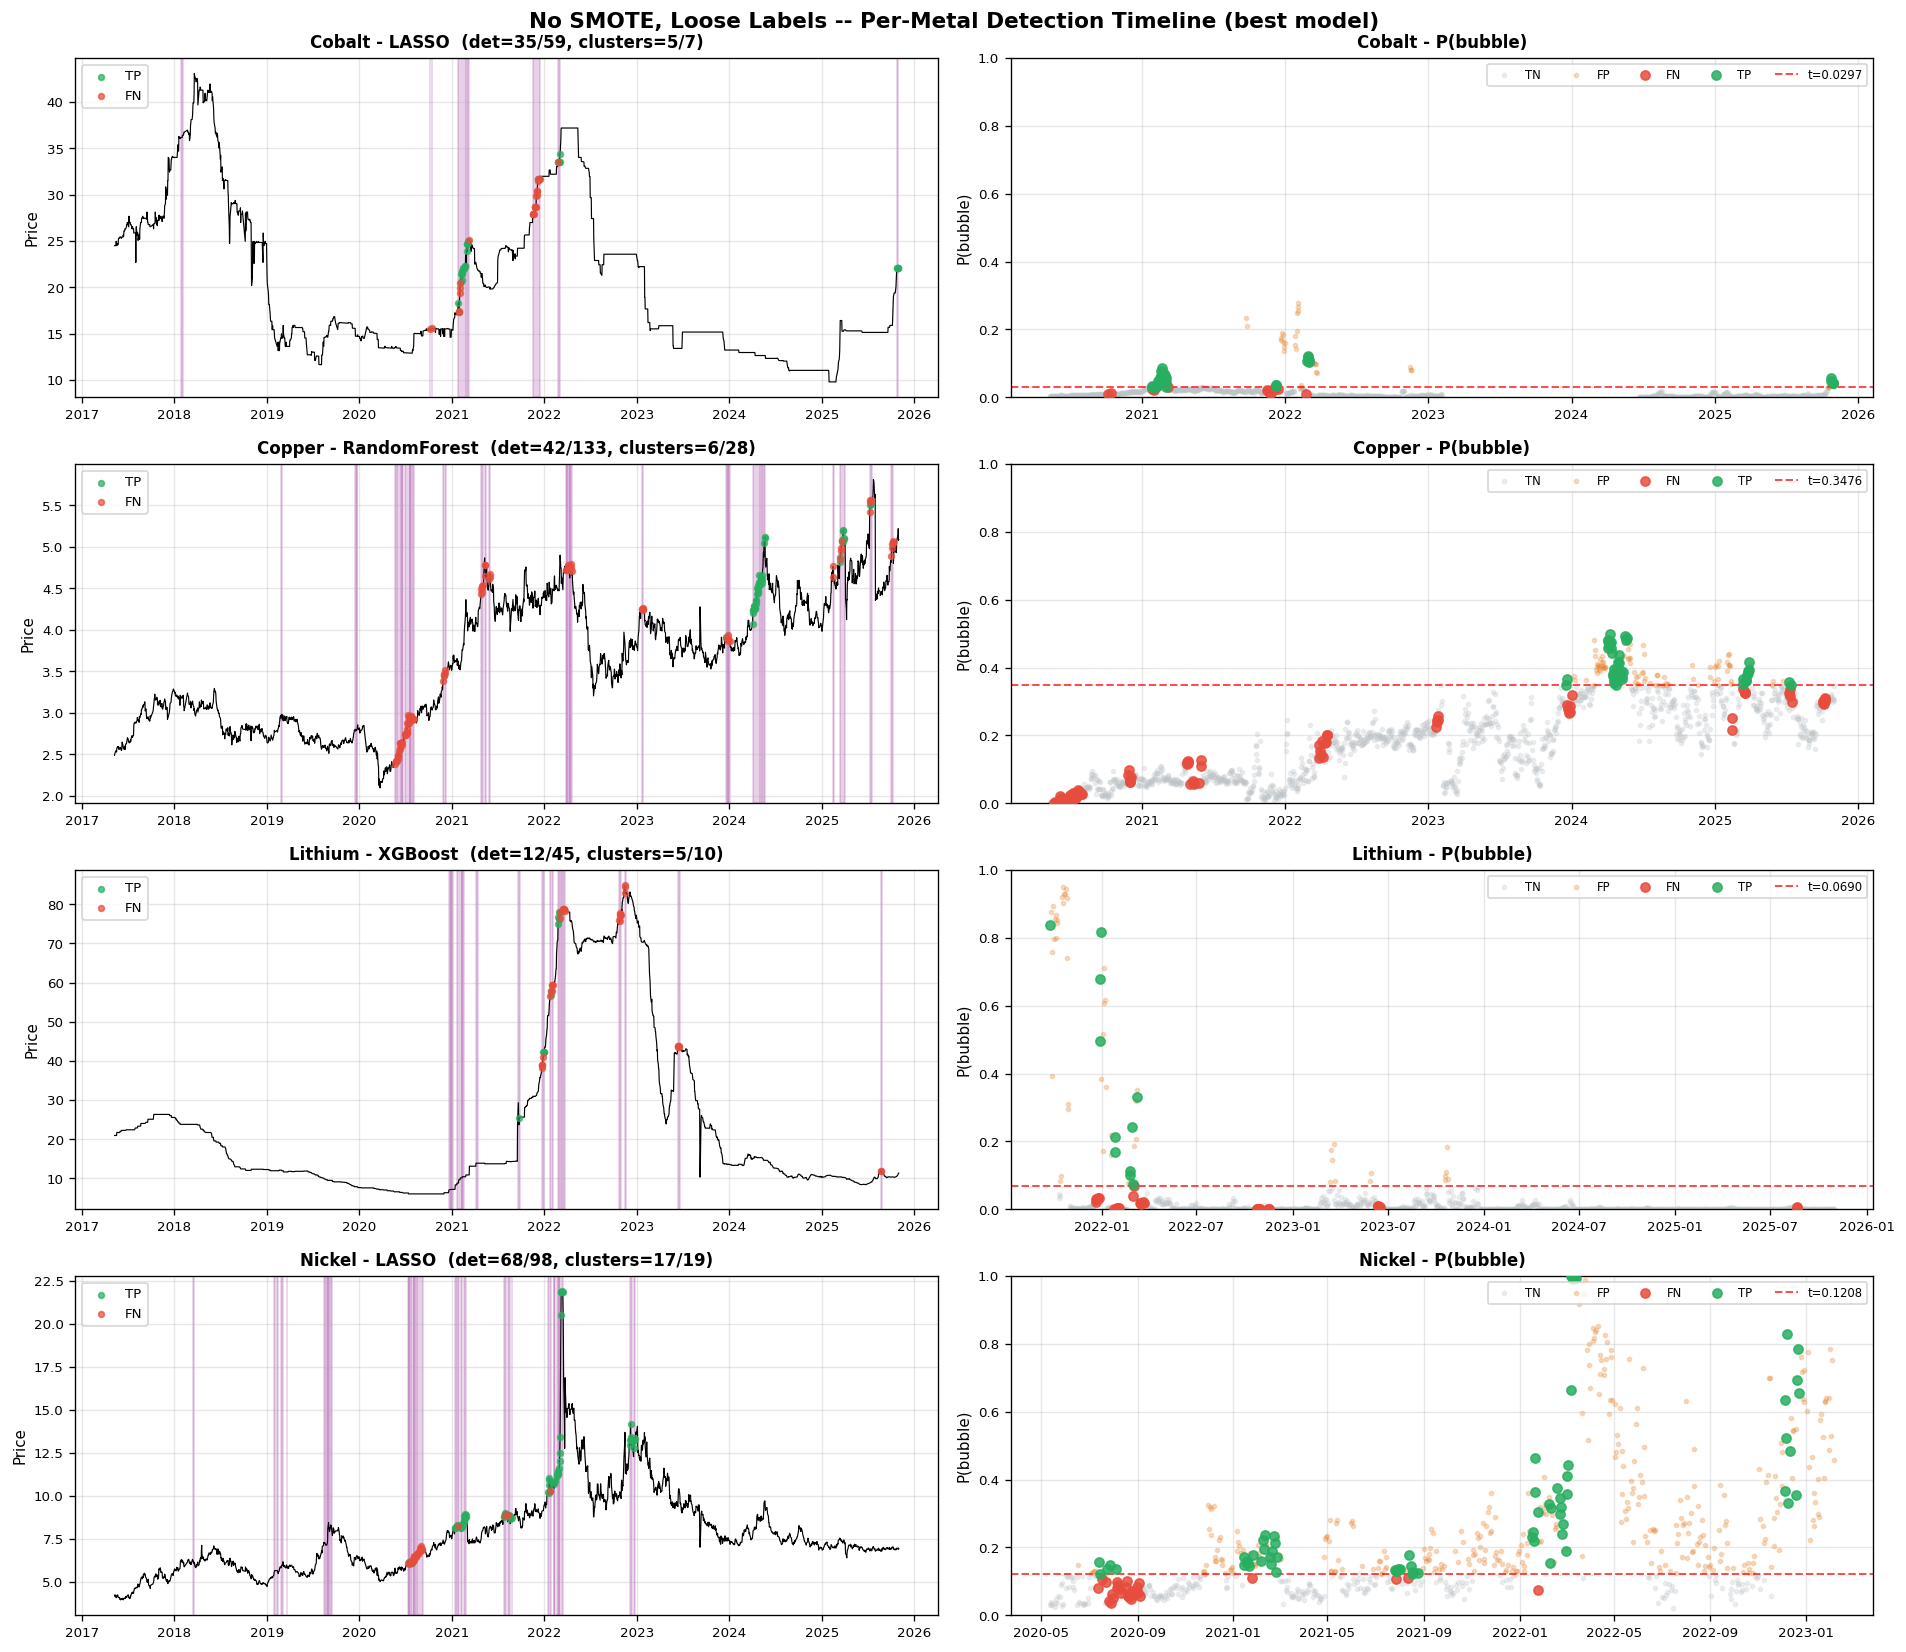

Saved -> outputs/nosmote_timelines.png


In [5]:
# ── Pick best model per metal (by F1) for the timeline ──────────────────────
best_model = {}
for metal in ['Cobalt', 'Copper', 'Lithium', 'Nickel']:
    sub = df_res[df_res.Metal == metal].sort_values('F1_opt', ascending=False)
    best_model[metal] = sub.iloc[0].Model

cls_colors = {'TP': '#27ae60', 'FP': '#e67e22', 'FN': '#e74c3c', 'TN': '#bdc3c7'}

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for idx, (metal, (pcol, dcol)) in enumerate(metal_map.items()):
    mname = best_model[metal]
    key = (metal, mname)
    if key not in cv_preds:
        continue
    pred = cv_preds[key].copy()
    opt_t = df_res[(df_res.Metal==metal) & (df_res.Model==mname)].iloc[0].T_opt
    pred['y_pred'] = (pred['y_prob'] >= opt_t).astype(int)
    pred['cls'] = pred.apply(
        lambda r: ('TP' if r.y_true==1 and r.y_pred==1 else
                   'FN' if r.y_true==1 and r.y_pred==0 else
                   'FP' if r.y_true==0 and r.y_pred==1 else 'TN'), axis=1)

    # Left: price + bubble shading
    ax0 = axes[idx, 0]
    ax0.plot(df['Date'], df[pcol], color='black', lw=0.7)
    bub = df[dcol].values
    in_b = False
    for i in range(len(bub)):
        if bub[i]==1 and not in_b:
            s=df['Date'].iloc[i]; in_b=True
        elif (bub[i]==0 or i==len(bub)-1) and in_b:
            ax0.axvspan(s, df['Date'].iloc[i], color='purple', alpha=0.18)
            in_b = False
    # Mark TP/FN on price chart
    tp_m = pred[pred.cls=='TP']
    fn_m = pred[pred.cls=='FN']
    merged = df[['Date', pcol]].merge(pred[['Date','cls']], on='Date', how='inner')
    tp_rows = merged[merged.cls=='TP']
    fn_rows = merged[merged.cls=='FN']
    ax0.scatter(tp_rows['Date'], tp_rows[pcol], c='#27ae60', s=12, alpha=0.7, zorder=4, label='TP')
    ax0.scatter(fn_rows['Date'], fn_rows[pcol], c='#e74c3c', s=12, alpha=0.7, zorder=4, label='FN')

    det_str = df_res[(df_res.Metal==metal) & (df_res.Model==mname)].iloc[0].Detected
    cl_str  = df_res[(df_res.Metal==metal) & (df_res.Model==mname)].iloc[0].ClustersDet
    ax0.set_title(f'{metal} - {mname}  (det={det_str}, clusters={cl_str})',
                  fontsize=10, fontweight='bold')
    ax0.legend(fontsize=8, loc='upper left')
    ax0.tick_params(labelsize=8)
    ax0.set_ylabel('Price', fontsize=9)
    ax0.grid(alpha=0.3)

    # Right: predicted probabilities
    ax1 = axes[idx, 1]
    for cls in ['TN', 'FP', 'FN', 'TP']:
        sub = pred[pred.cls==cls]
        sz = 30 if cls in ('TP','FN') else 6
        al = 0.85 if cls in ('TP','FN') else 0.25
        zo = 5 if cls in ('TP','FN') else 2
        ax1.scatter(sub['Date'], sub['y_prob'], c=cls_colors[cls],
                    s=sz, alpha=al, label=cls, zorder=zo)
    ax1.axhline(opt_t, color='red', ls='--', lw=1.2, alpha=0.7,
                label=f't={opt_t:.4f}')
    ax1.set_ylim(0, 1)
    ax1.set_title(f'{metal} - P(bubble)', fontsize=10, fontweight='bold')
    ax1.legend(fontsize=7, loc='upper right', ncol=5)
    ax1.tick_params(labelsize=8)
    ax1.set_ylabel('P(bubble)', fontsize=9)
    ax1.grid(alpha=0.3)

plt.suptitle('No SMOTE, Loose Labels -- Per-Metal Detection Timeline (best model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/nosmote_timelines.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved -> outputs/nosmote_timelines.png')


## 5. Comparison: Loose No-SMOTE vs Relaxed SMOTE

Load previous SMOTE results and compare side by side.

In [6]:
# ── Load SMOTE results for comparison ────────────────────────────────────────
smote_path = 'outputs/smote_results_all_metals.csv'
if os.path.exists(smote_path):
    df_smote = pd.read_csv(smote_path)
    # Best per metal from SMOTE
    smote_best = df_smote.loc[df_smote.groupby('Metal')['F1_opt'].idxmax()].copy()
    # Best per metal from no-SMOTE
    nosmote_best = df_res.loc[df_res.groupby('Metal')['F1_opt'].idxmax()].copy()

    print('Comparison: Best Model per Metal')
    print('=' * 85)
    print(f'{"Metal":>8s}  {"Approach":>20s}  {"Model":>15s}  '
          f'{"AUC":>5s}  {"F1":>5s}  {"Sens":>5s}  {"Detected":>8s}  {"Clusters":>9s}')
    print('-' * 85)

    for metal in ['Cobalt', 'Copper', 'Lithium', 'Nickel']:
        # SMOTE row
        sr = smote_best[smote_best.Metal == metal].iloc[0]
        print(f'{metal:>8s}  {"SMOTE+relaxed":>20s}  {sr.Model:>15s}  '
              f'{sr.AUC:>5.3f}  {sr.F1_opt:>5.3f}  {sr.Sens_opt:>5.3f}  '
              f'{sr.Det_opt:>8s}  {"n/a":>9s}')
        # No-SMOTE row
        nr = nosmote_best[nosmote_best.Metal == metal].iloc[0]
        print(f'{"":>8s}  {"NoSMOTE+loose":>20s}  {nr.Model:>15s}  '
              f'{nr.AUC:>5.3f}  {nr.F1_opt:>5.3f}  {nr.Sens:>5.3f}  '
              f'{nr.Detected:>8s}  {nr.ClustersDet:>9s}')
        print()
else:
    print(f'{smote_path} not found -- run the relaxed notebook first for comparison.')


Comparison: Best Model per Metal
   Metal              Approach            Model    AUC     F1   Sens  Detected   Clusters
-------------------------------------------------------------------------------------
  Cobalt         SMOTE+relaxed            LASSO  0.949  0.333  0.400       2/5        n/a
                 NoSMOTE+loose            LASSO  0.909  0.515  0.593     35/59        5/7

  Copper         SMOTE+relaxed            LASSO  0.718  0.196  0.152      5/33        n/a
                 NoSMOTE+loose     RandomForest  0.543  0.311  0.316    42/133       6/28

 Lithium         SMOTE+relaxed            LASSO  0.750  0.194  0.613     19/31        n/a
                 NoSMOTE+loose          XGBoost  0.744  0.224  0.267     12/45       5/10

  Nickel         SMOTE+relaxed            LASSO  0.423  0.116  0.216      8/37        n/a
                 NoSMOTE+loose            LASSO  0.549  0.264  0.694     68/98      17/19



## 6. Period-Based Labels — Train Models on Coherent Bubble Episodes

The loose labels (Section 2–5) flag **individual scattered days** wherever LPPLS
confidence exceeds 0.05. In contrast, GSADF identifies **entire contiguous periods**.

In Section 9 of `lppls_data_prep.ipynb`, we converted raw LPPLS confidence into
coherent bubble periods using: smoothing → threshold → trend filter → gap bridging
→ minimum duration (following Cao et al. 2025; Zhang et al. 2016; Shu & Zhu 2020).

Now we retrain the same 3 models (LASSO, RF, XGBoost) on these period-based labels
and compare cluster detection vs the point-wise approach.

Period: 2017-05-10 to 2025-10-31 (2152 days)

Metal        Days   Prev%  Episodes  Avg Len
--------------------------------------------
Cobalt         71    3.3%         5     14.2d
Copper        179    8.3%        15     11.9d
Lithium        73    3.4%        10      7.3d
Nickel        193    9.0%        10     19.3d


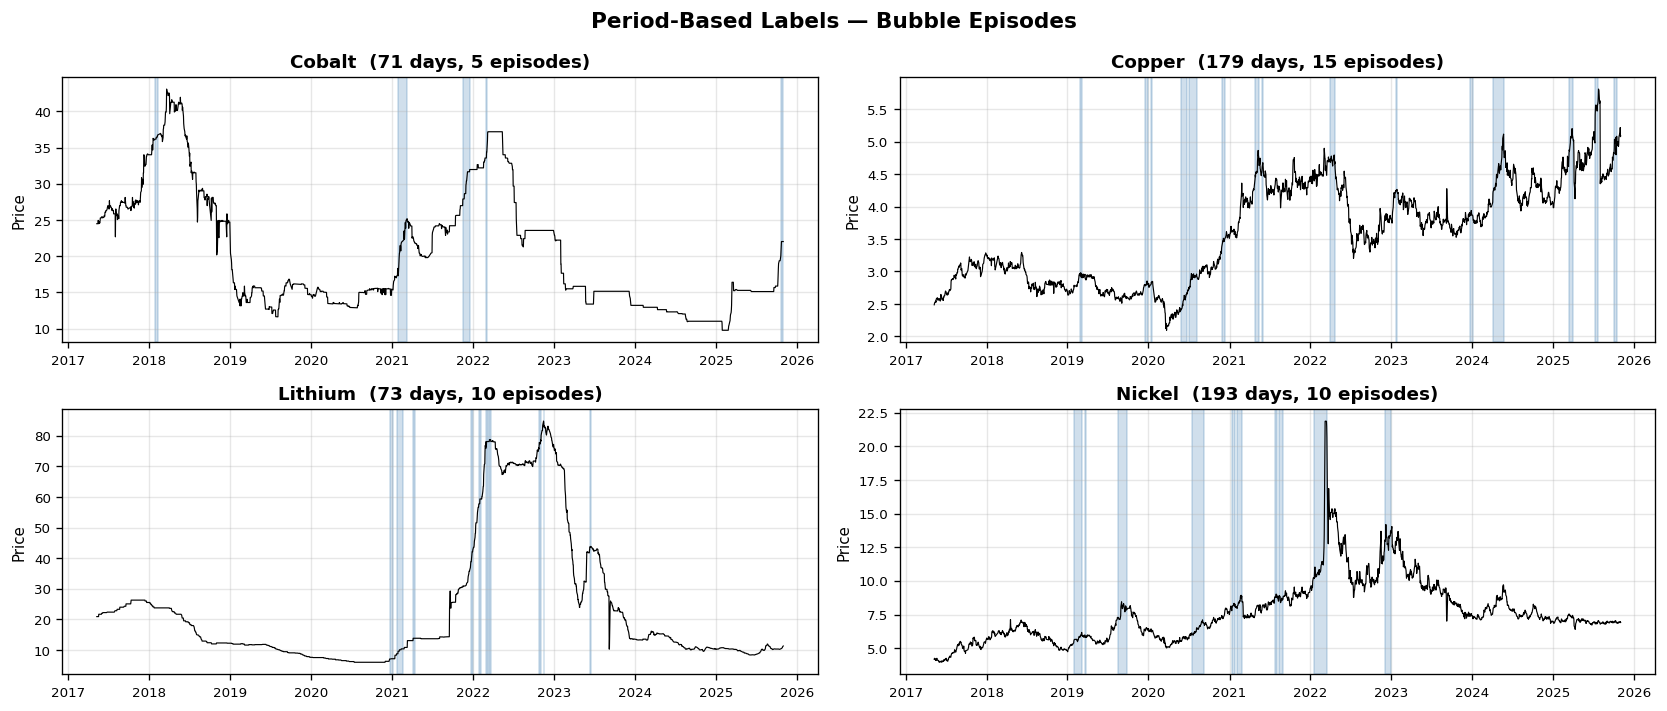

In [7]:
# ── Load period-based labels ─────────────────────────────────────────────────
PERIOD_CSV = '../R/df_master_lppls_periods.csv'
assert os.path.exists(PERIOD_CSV), (
    f'{PERIOD_CSV} not found -- run lppls_data_prep.ipynb Section 9 first')

df_per = pd.read_csv(PERIOD_CSV, sep=';', decimal=',', index_col=0)
df_per['Date'] = pd.to_datetime(df_per['Date'])
df_per = df_per.sort_values('Date').reset_index(drop=True)

print(f'Period: {df_per["Date"].min().date()} to {df_per["Date"].max().date()} ({len(df_per)} days)\n')
print(f'{"Metal":10s}  {"Days":>5s}  {"Prev%":>6s}  {"Episodes":>8s}  {"Avg Len":>7s}')
print('-' * 44)
for metal, (pcol, dcol) in metal_map.items():
    bub = df_per[dcol].values
    n = int(bub.sum())
    cl = label_clusters(bub)
    nc = cl.max()
    # avg episode length
    ep_lens = []
    i = 0
    while i < len(bub):
        if bub[i] == 1:
            j = i
            while j < len(bub) and bub[j] == 1:
                j += 1
            ep_lens.append(j - i)
            i = j
        else:
            i += 1
    avg_l = np.mean(ep_lens) if ep_lens else 0
    print(f'{metal:10s}  {n:5d}  {100*n/len(df_per):5.1f}%  {nc:8d}  {avg_l:7.1f}d')

# ── Timeline with episodes shaded ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for idx, (metal, (pcol, dcol)) in enumerate(metal_map.items()):
    ax = axes.flat[idx]
    dates = df_per['Date']
    ax.plot(dates, df_per[pcol], color='black', lw=0.7)
    bub = df_per[dcol].values
    cl = label_clusters(bub)
    nc = cl.max()
    in_b = False
    for i in range(len(bub)):
        if bub[i] == 1 and not in_b:
            s = dates.iloc[i]; in_b = True
        elif (bub[i] == 0 or i == len(bub) - 1) and in_b:
            ax.axvspan(s, dates.iloc[i], color='steelblue', alpha=0.25)
            in_b = False
    ax.set_title(f'{metal}  ({int(bub.sum())} days, {nc} episodes)',
                 fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.set_ylabel('Price', fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle('Period-Based Labels — Bubble Episodes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/period_bubble_timelines.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### 6b. Train LASSO / RF / XGBoost on Period-Based Labels

In [8]:
# ── Train on period-based labels (same pipeline as Section 2) ────────────────
results_per = []
cv_preds_per = {}

for metal, (pcol, dcol) in metal_map.items():
    df_ml_per = prepare_ml_data(pcol, df_per)
    feats_per = [c for c in df_ml_per.columns if c not in ['Date', 'Target']]
    X_per = df_ml_per[feats_per].values
    y_per = df_ml_per['Target'].values
    dates_per = df_ml_per['Date']

    n_pos_per = int(y_per.sum())
    print(f'\n{metal}  --  {n_pos_per} bubble days / {len(y_per)} total ({100*y_per.mean():.1f}%)')

    for mname, model_fn in models_def.items():
        scale = (mname == 'LASSO')
        tscv = TimeSeriesSplit(n_splits=N_SPLITS)
        all_p, all_t, all_d = [], [], []

        for train_idx, test_idx in tscv.split(X_per):
            Xtr, Xte = X_per[train_idx], X_per[test_idx]
            ytr, yte = y_per[train_idx], y_per[test_idx]
            d_te = dates_per.iloc[test_idx].values

            if ytr.sum() < 5 or yte.sum() == 0:
                continue

            if scale:
                sc = StandardScaler()
                Xtr = sc.fit_transform(Xtr)
                Xte = sc.transform(Xte)

            m = model_fn()
            m.fit(Xtr, ytr)
            p = m.predict_proba(Xte)[:, 1]
            all_p.append(p); all_t.append(yte); all_d.append(d_te)

        if not all_p:
            print(f'  {mname:15s}: no valid fold')
            continue

        pred_df = pd.DataFrame({
            'Date': pd.to_datetime(np.concatenate(all_d)),
            'y_true': np.concatenate(all_t),
            'y_prob': np.concatenate(all_p),
        }).sort_values('Date').reset_index(drop=True)
        cv_preds_per[(metal, mname)] = pred_df

        yt = pred_df['y_true'].values
        yp = pred_df['y_prob'].values
        auc = roc_auc_score(yt, yp)
        opt_t, opt_f1 = find_f1_threshold(yt, yp)
        ypred = (yp >= opt_t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yt, ypred, labels=[0,1]).ravel()
        sens = tp/(tp+fn) if (tp+fn) > 0 else 0
        spec = tn/(tn+fp) if (tn+fp) > 0 else 0
        prec = tp/(tp+fp) if (tp+fp) > 0 else 0

        # Per-cluster (episode) detection
        cl = label_clusters(pred_df['y_true'].values)
        clusters_total = set(cl[cl > 0])
        detected_clusters = set()
        for c_id in clusters_total:
            mask = cl == c_id
            if ypred[mask].sum() > 0:
                detected_clusters.add(c_id)
        n_cl_det = len(detected_clusters)
        n_cl_tot = len(clusters_total)

        results_per.append(dict(
            Metal=metal, Model=mname, BubDays=n_pos_per,
            AUC=round(auc, 3), F1_opt=round(opt_f1, 3), T_opt=round(opt_t, 4),
            Sens=round(sens, 3), Spec=round(spec, 3), Prec=round(prec, 3),
            Detected=f'{tp}/{tp+fn}',
            EpisodesDet=f'{n_cl_det}/{n_cl_tot}',
        ))
        print(f'  {mname:15s}:  AUC={auc:.3f}  F1={opt_f1:.3f}  '
              f'Sens={sens:.3f}  Det={tp}/{tp+fn}  '
              f'Episodes={n_cl_det}/{n_cl_tot}')

df_res_per = pd.DataFrame(results_per)
df_res_per.to_csv('outputs/nosmote_period_results.csv', index=False)
print(f'\nSaved -> outputs/nosmote_period_results.csv')


Cobalt  --  71 bubble days / 2141 total (3.3%)
  LASSO          :  AUC=0.826  F1=0.317  Sens=0.857  Det=54/63  Episodes=4/4
  RandomForest   :  AUC=0.753  F1=0.225  Sens=0.857  Det=54/63  Episodes=4/4
  XGBoost        :  AUC=0.700  F1=0.186  Sens=0.587  Det=37/63  Episodes=4/4

Copper  --  179 bubble days / 2141 total (8.4%)
  LASSO          :  AUC=0.579  F1=0.279  Sens=0.488  Det=79/162  Episodes=6/12
  RandomForest   :  AUC=0.568  F1=0.297  Sens=0.346  Det=56/162  Episodes=4/12
  XGBoost        :  AUC=0.584  F1=0.232  Sens=0.938  Det=152/162  Episodes=11/12

Lithium  --  73 bubble days / 2141 total (3.4%)
  LASSO          :  AUC=0.635  F1=0.165  Sens=0.650  Det=26/40  Episodes=5/7
  RandomForest   :  AUC=0.307  F1=0.108  Sens=1.000  Det=40/40  Episodes=7/7
  XGBoost        :  AUC=0.562  F1=0.164  Sens=0.150  Det=6/40  Episodes=2/7

Nickel  --  193 bubble days / 2141 total (9.0%)
  LASSO          :  AUC=0.501  F1=0.346  Sens=1.000  Det=138/138  Episodes=7/7
  RandomForest   :  AUC=0.

### 6c. Results & Comparison: Point-Wise vs Period-Based Labels

═══════════════════════════════════════════════════════════════════════════════════════════════
Comparison: Point-Wise Loose vs Period-Based Labels  (best model per metal)
═══════════════════════════════════════════════════════════════════════════════════════════════

   Metal         Approach         Model    AUC     F1   Sens   Prec  Detected   Episodes
-----------------------------------------------------------------------------------------------
  Cobalt       Point-wise         LASSO  0.909  0.515  0.593  0.455     35/59        5/7
             Period-based         LASSO  0.826  0.317  0.857  0.194     54/63        4/4

  Copper       Point-wise  RandomForest  0.543  0.311  0.316  0.307    42/133       6/28
             Period-based  RandomForest  0.568  0.297  0.346  0.260    56/162       4/12

 Lithium       Point-wise       XGBoost  0.744  0.224  0.267  0.194     12/45       5/10
             Period-based         LASSO  0.635  0.165  0.650  0.095     26/40        5/7

  Nickel 

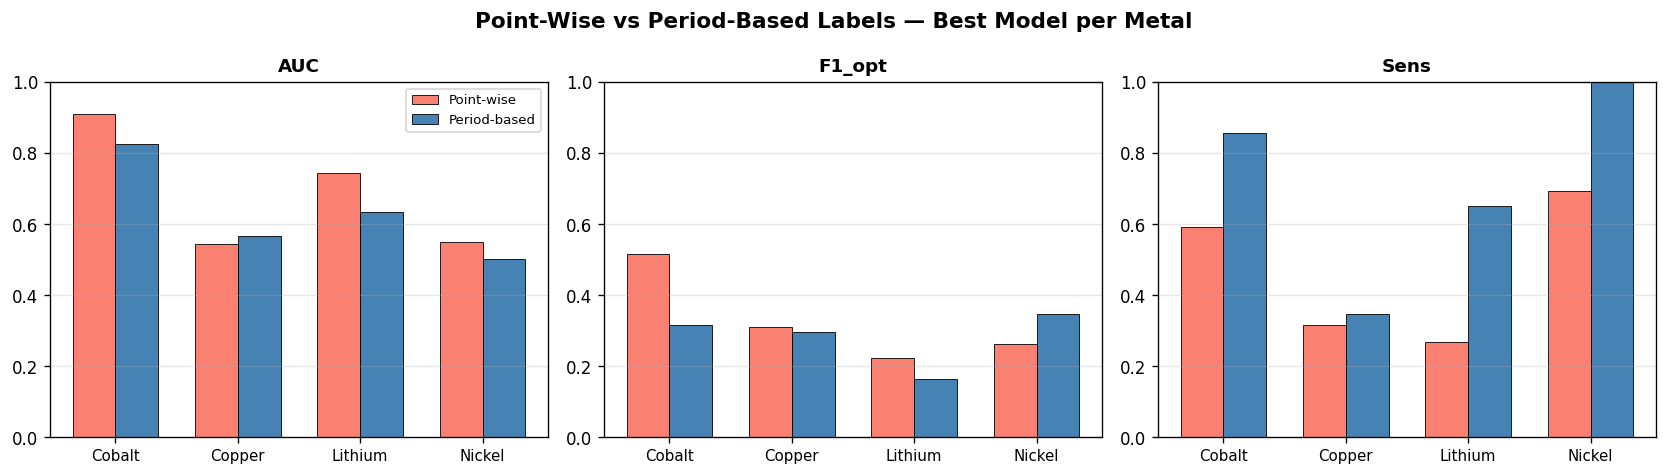

Saved -> outputs/pointwise_vs_period_comparison.png


In [9]:
# ── Side-by-side comparison: point-wise loose vs period-based ────────────────
print('═' * 95)
print('Comparison: Point-Wise Loose vs Period-Based Labels  (best model per metal)')
print('═' * 95)

pw_best = df_res.loc[df_res.groupby('Metal')['F1_opt'].idxmax()].copy()
per_best = df_res_per.loc[df_res_per.groupby('Metal')['F1_opt'].idxmax()].copy()

print(f'\n{"Metal":>8s}  {"Approach":>15s}  {"Model":>12s}  '
      f'{"AUC":>5s}  {"F1":>5s}  {"Sens":>5s}  {"Prec":>5s}  '
      f'{"Detected":>8s}  {"Episodes":>9s}')
print('-' * 95)

for metal in ['Cobalt', 'Copper', 'Lithium', 'Nickel']:
    # Point-wise row
    r1 = pw_best[pw_best.Metal == metal].iloc[0]
    print(f'{metal:>8s}  {"Point-wise":>15s}  {r1.Model:>12s}  '
          f'{r1.AUC:>5.3f}  {r1.F1_opt:>5.3f}  {r1.Sens:>5.3f}  {r1.Prec:>5.3f}  '
          f'{r1.Detected:>8s}  {r1.ClustersDet:>9s}')
    # Period-based row
    r2 = per_best[per_best.Metal == metal].iloc[0]
    print(f'{"":>8s}  {"Period-based":>15s}  {r2.Model:>12s}  '
          f'{r2.AUC:>5.3f}  {r2.F1_opt:>5.3f}  {r2.Sens:>5.3f}  {r2.Prec:>5.3f}  '
          f'{r2.Detected:>8s}  {r2.EpisodesDet:>9s}')
    print()

# ── Bar chart comparison ────────────────────────────────────────────────────
met_order = ['Cobalt', 'Copper', 'Lithium', 'Nickel']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax_idx, metric in enumerate(['AUC', 'F1_opt', 'Sens']):
    ax = axes[ax_idx]
    x = np.arange(len(met_order))
    vals_pw = [pw_best[pw_best.Metal==m].iloc[0][metric] for m in met_order]
    vals_per = [per_best[per_best.Metal==m].iloc[0][metric] for m in met_order]
    w = 0.35
    ax.bar(x - w/2, vals_pw, w, label='Point-wise', color='salmon', edgecolor='black', lw=0.5)
    ax.bar(x + w/2, vals_per, w, label='Period-based', color='steelblue', edgecolor='black', lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(met_order, fontsize=9)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    if ax_idx == 0:
        ax.legend(fontsize=8)

plt.suptitle('Point-Wise vs Period-Based Labels — Best Model per Metal',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/pointwise_vs_period_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved -> outputs/pointwise_vs_period_comparison.png')

### 6d. Per-Metal Timeline Plots (Period-Based)

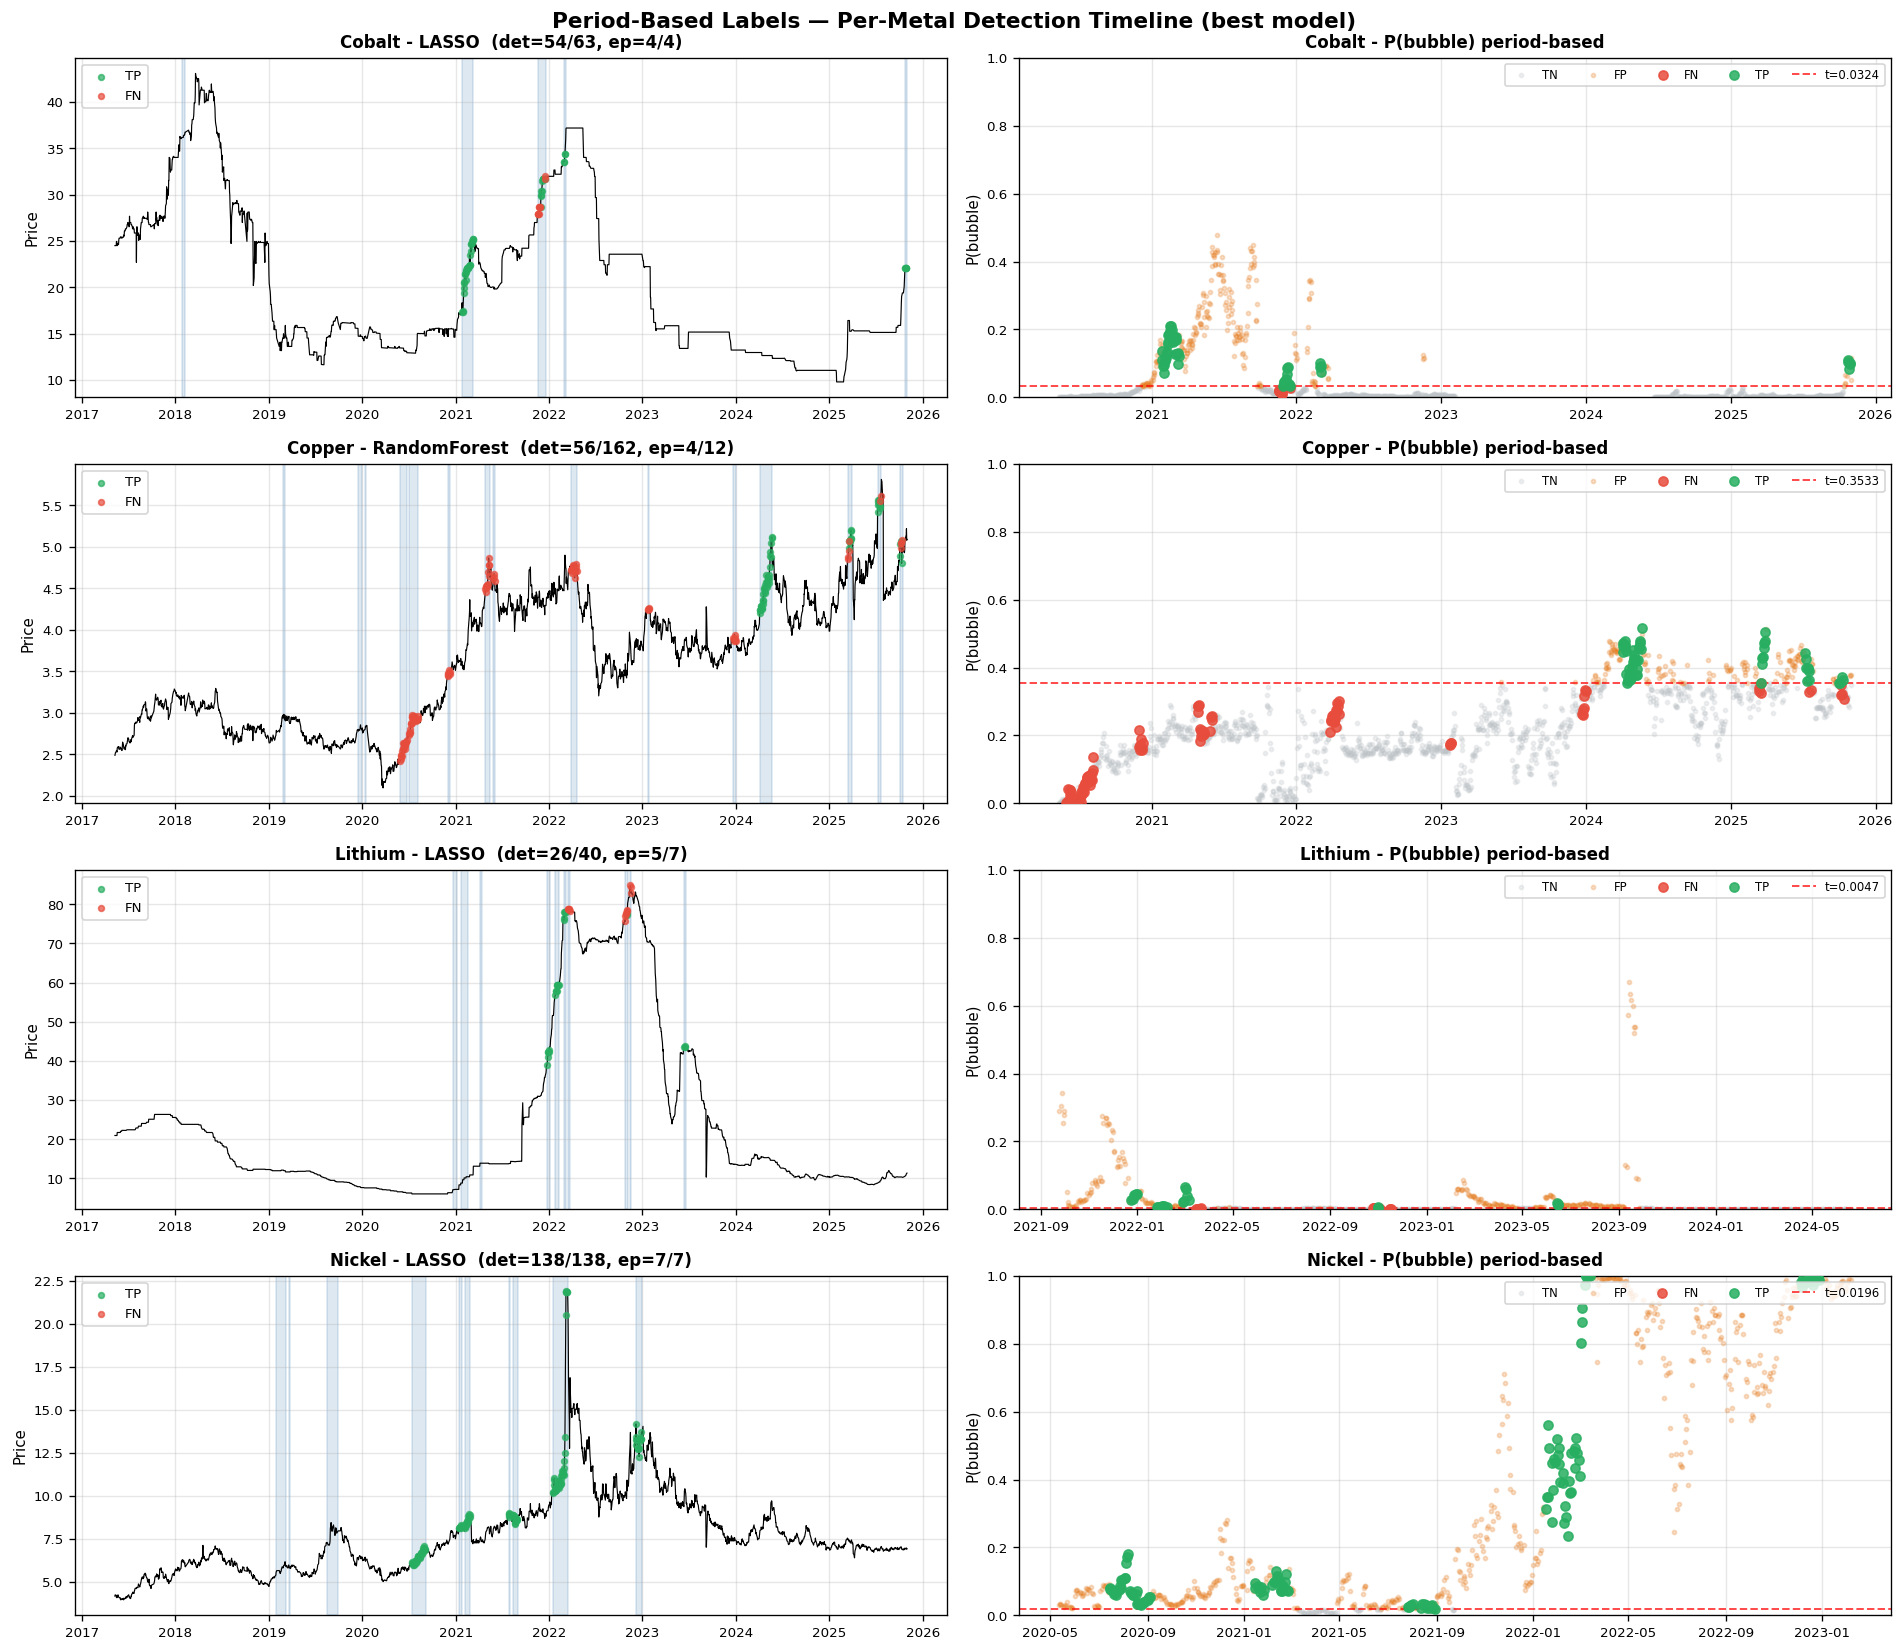

Saved -> outputs/period_timelines.png


In [10]:
# ── Timeline plots for period-based predictions ─────────────────────────────
best_model_per = {}
for metal in ['Cobalt', 'Copper', 'Lithium', 'Nickel']:
    sub = df_res_per[df_res_per.Metal == metal].sort_values('F1_opt', ascending=False)
    if len(sub) > 0:
        best_model_per[metal] = sub.iloc[0].Model

fig, axes = plt.subplots(4, 2, figsize=(16, 14))

for idx, (metal, (pcol, dcol)) in enumerate(metal_map.items()):
    mname = best_model_per.get(metal)
    if not mname:
        continue
    key = (metal, mname)
    if key not in cv_preds_per:
        continue
    pred = cv_preds_per[key].copy()
    r = df_res_per[(df_res_per.Metal==metal) & (df_res_per.Model==mname)].iloc[0]
    opt_t = r.T_opt
    pred['y_pred'] = (pred['y_prob'] >= opt_t).astype(int)
    pred['cls'] = pred.apply(
        lambda r: ('TP' if r.y_true==1 and r.y_pred==1 else
                   'FN' if r.y_true==1 and r.y_pred==0 else
                   'FP' if r.y_true==0 and r.y_pred==1 else 'TN'), axis=1)

    # Left: price + episode shading
    ax0 = axes[idx, 0]
    ax0.plot(df_per['Date'], df_per[pcol], color='black', lw=0.7)
    bub = df_per[dcol].values
    in_b = False
    for i in range(len(bub)):
        if bub[i]==1 and not in_b:
            s=df_per['Date'].iloc[i]; in_b=True
        elif (bub[i]==0 or i==len(bub)-1) and in_b:
            ax0.axvspan(s, df_per['Date'].iloc[i], color='steelblue', alpha=0.18)
            in_b = False
    # Mark TP/FN
    merged = df_per[['Date', pcol]].merge(pred[['Date','cls']], on='Date', how='inner')
    tp_rows = merged[merged.cls=='TP']
    fn_rows = merged[merged.cls=='FN']
    ax0.scatter(tp_rows['Date'], tp_rows[pcol], c='#27ae60', s=12, alpha=0.7, zorder=4, label='TP')
    ax0.scatter(fn_rows['Date'], fn_rows[pcol], c='#e74c3c', s=12, alpha=0.7, zorder=4, label='FN')

    ax0.set_title(f'{metal} - {mname}  (det={r.Detected}, ep={r.EpisodesDet})',
                  fontsize=10, fontweight='bold')
    ax0.legend(fontsize=8, loc='upper left')
    ax0.tick_params(labelsize=8)
    ax0.set_ylabel('Price', fontsize=9)
    ax0.grid(alpha=0.3)

    # Right: predicted probabilities
    ax1 = axes[idx, 1]
    for cls in ['TN', 'FP', 'FN', 'TP']:
        sub = pred[pred.cls==cls]
        sz = 30 if cls in ('TP','FN') else 6
        al = 0.85 if cls in ('TP','FN') else 0.25
        zo = 5 if cls in ('TP','FN') else 2
        ax1.scatter(sub['Date'], sub['y_prob'], c=cls_colors[cls],
                    s=sz, alpha=al, label=cls, zorder=zo)
    ax1.axhline(opt_t, color='red', ls='--', lw=1.2, alpha=0.7,
                label=f't={opt_t:.4f}')
    ax1.set_ylim(0, 1)
    ax1.set_title(f'{metal} - P(bubble) period-based', fontsize=10, fontweight='bold')
    ax1.legend(fontsize=7, loc='upper right', ncol=5)
    ax1.tick_params(labelsize=8)
    ax1.set_ylabel('P(bubble)', fontsize=9)
    ax1.grid(alpha=0.3)

plt.suptitle('Period-Based Labels — Per-Metal Detection Timeline (best model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/period_timelines.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved -> outputs/period_timelines.png')